# Wikipedia HTML Feature Extractor
This notebook parses saved Wikipedia HTML files (like A Wiki of Ice and Fire) and extracts 46 distinct features into a structured Pandas DataFrame. It handles missing data gracefully to ensure every file produces the exact same column structure.

## 1. Setup & Imports

All dependencies are loaded here so every subsequent cell can run cleanly in order.

In [40]:
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import os
import ast
import glob
import warnings
from typing import Dict, List, Any
from concurrent.futures import ThreadPoolExecutor, as_completed

import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial import distance

# Suppress minor BeautifulSoup warnings for clean output
warnings.filterwarnings("ignore", category=UserWarning, module='bs4')

## 2. `WikiHTMLParser` Class

This class wraps a single Wikipedia HTML page and exposes extraction methods grouped into 11 feature families (identity, names, infobox, books, text, structure, links, categories, images, navboxes, page size). `parse_all()` aggregates every family into a single-row DataFrame.

In [41]:
class WikiHTMLParser:
    """Parser for extracting features from wiki HTML for Search Indexing"""
    
    def __init__(self, html_content: str, valid_pages: List[str] = None):
        self.soup = BeautifulSoup(html_content, 'html.parser')
        # Passed in to filter links, equivalent to your global `pages` list
        self.pages = valid_pages if valid_pages is not None else []
    
    # 1. IDENTITY
    def extract_identity_features(self) -> Dict[str, Any]:
        identity = {'title': None, 'og_title': None, 'infobox_name': None, 
                    'meta_description': None, 'hatnote': None, 
                    'article_id': None, 'canonical_url': None}
        
        title_tag = self.soup.find('title')
        identity['title'] = title_tag.text.replace(' - A Wiki of Ice and Fire', '').strip() if title_tag else None
        
        og_title = self.soup.find('meta', property='og:title')
        identity['og_title'] = og_title.get('content') if og_title else None
        
        infobox = self.soup.find('table', class_='infobox')
        if infobox:
            heading = infobox.find('th', colspan='2')
            identity['infobox_name'] = heading.text.strip() if heading else None
        
        meta_desc = self.soup.find('meta', attrs={'name': 'description'})
        identity['meta_description'] = meta_desc.get('content') if meta_desc else None
        
        hatnote = self.soup.find('div', class_='hatnote')
        identity['hatnote'] = hatnote.text.strip() if hatnote else None
        
        article_id_match = re.search(r'"wgArticleId":(\d+)', str(self.soup))
        identity['article_id'] = int(article_id_match.group(1)) if article_id_match else None
        
        canonical = self.soup.find('link', rel='canonical')
        identity['canonical_url'] = canonical.get('href') if canonical else None
        return identity
    
    # 2. NAMES
    def extract_names_features(self) -> Dict[str, Any]:
        names = {'aliases': [], 'char_titles': [], 'all_name_variants': [], 'first_name': None, 'last_name': None}
        heading = self.soup.find('h1', id='firstHeading')
        full_name = heading.text.strip() if heading else None
        
        if full_name:
            parts = full_name.split()
            names['first_name'] = parts[0]
            names['last_name'] = parts[-1] if len(parts) > 1 else None
            
        infobox = self.soup.find('table', class_='infobox')
        if infobox:
            aliases_row = infobox.find('th', string=re.compile('Aliases', re.I))
            # Update Aliases
            if aliases_row and aliases_row.find_next('td'):
                items = aliases_row.find_next('td').find_all('li')
                names['aliases'] = [re.sub(r'\[\d+\]', '', li.text).strip() for li in items] if items else [re.sub(r'\[\d+\]', '', aliases_row.find_next('td').text).strip()]
            
            # Update Titles
            titles_row = infobox.find('th', string=re.compile('Titles', re.I))
            if titles_row and titles_row.find_next('td'):
                items = titles_row.find_next('td').find_all('li')
                names['char_titles'] = [re.sub(r'\[\d+\]', '', li.text).strip() for li in items] if items else [re.sub(r'\[\d+\]', '', titles_row.find_next('td').text).strip()]
        
        base_names = [n for n in [names['first_name'], names['last_name']] if n]
        names['all_name_variants'] = list(set(base_names + names['aliases'] + names['char_titles']))
        return names
    
    # 3. INFOBOX
    def extract_infobox_features(self) -> Dict[str, Any]:
        info = {'allegiances': [], 'culture': None, 'born': None, 'died': None, 
                'father': None, 'mother': None, 'spouses': None, 'played_by': None, 'infobox_fields_count': 0}
        
        infobox = self.soup.find('table', class_='infobox')
        if not infobox: return info
        
        for row in infobox.find_all('tr'):
            th = row.find('th', scope='row')
            td = row.find('td')
            if th and td:
                info['infobox_fields_count'] += 1
                label, value = th.text.strip().lower(), td.text.strip()
                if 'allegiance' in label:
                    links = td.find_all('a')
                    info['allegiances'] = [a.text.strip() for a in links] if links else [value]
                elif 'culture' in label: info['culture'] = value
                elif 'born' in label: info['born'] = value
                elif 'died' in label: info['died'] = value
                elif 'father' in label: info['father'] = td.find('a').text.strip() if td.find('a') else value
                elif 'mother' in label: info['mother'] = td.find('a').text.strip() if td.find('a') else value
                elif 'spouse' in label or 'wife' in label or 'husband' in label: info['spouses'] = value
                elif 'played by' in label: info['played_by'] = value
        return info
    
    # 4. BOOKS
    def extract_books_features(self) -> Dict[str, Any]:
        books_data = {'books': [], 'book_count': 0, 'is_pov': False, 'book_roles': {}}
        infobox = self.soup.find('table', class_='infobox')
        if infobox:
            books_row = infobox.find('th', string=re.compile('Books', re.I))
            if books_row and books_row.find_next('td'):
                for item in books_row.find_next('td').find_all('li'):
                    text = item.text.strip()
                    books_data['books'].append(text)
                    if 'POV' in text:
                        books_data['is_pov'] = True
                        books_data['book_roles'][text] = 'POV'
        books_data['book_count'] = len(books_data['books'])
        return books_data
    
    # 5. TEXT (FIXED)
    def extract_text_features(self) -> Dict[str, Any]:
        text_data = {'text': "", 'text_length': 0, 'word_count': 0, 'paragraph_count': 0}
        # Fixed: Changed class_='mw-content-text' to id='mw-content-text'
        content = self.soup.find('div', id='mw-content-text')
        
        # Fallback to the whole page if the div isn't found
        if not content:
            content = self.soup

        paragraphs = content.find_all('p')
        text_data['paragraph_count'] = len(paragraphs)
        full_text = ' '.join([p.get_text() for p in paragraphs])
        text_data['text'] = full_text
        text_data['text_length'] = len(full_text)
        text_data['word_count'] = len(full_text.split())
            
        return text_data
    
    # 6. STRUCTURE
    def extract_structure_features(self) -> Dict[str, Any]:
        struct = {'sections': [], 'subsections': [], 'section_count': 0, 'quotes': [], 'quote_count': 0}
        for h2 in self.soup.find_all('h2'):
            if h2.find('span', class_='mw-headline'): struct['sections'].append(h2.text.strip())
        for h3 in self.soup.find_all('h3'):
            if h3.find('span', class_='mw-headline'): struct['subsections'].append(h3.text.strip())
        struct['section_count'] = len(struct['sections'])
        for bq in self.soup.find_all('blockquote', class_='templatequote'):
            if bq.find('p'): struct['quotes'].append(bq.find('p').text.strip())
        struct['quote_count'] = len(struct['quotes'])
        return struct
    
    # 7. LINKS & ANCHOR TEXTS (FIXED)
    def extract_links_features(self) -> Dict[str, Any]:
        links_data = {'links_out': [], 'links_out_count': 0, 'anchor_texts': []}
        # Fixed: Changed class_='mw-content-text' to id='mw-content-text'
        content = self.soup.find('div', id='mw-content-text')
        
        # Fallback to the whole page if the div isn't found
        if not content:
            content = self.soup

        for link in content.find_all('a', href=True):
            href = link.get('href')
            if href.startswith('/index.php/') or href.startswith('/wiki/'):
                target = link.get('title') or href.split('/')[-1].replace('_', ' ')
                anchor = link.text.strip()
                
                links_data['links_out'].append(target)
                if anchor and len(anchor) > 1:
                    links_data['anchor_texts'].append(anchor.lower())
                    
        links_data['links_out'] = list(set(links_data['links_out']))
        links_data['links_out_count'] = len(links_data['links_out'])
        links_data['anchor_texts'] = list(set(links_data['anchor_texts']))
        
        return links_data
    
    # 8. CATEGORIES
    def extract_categories_features(self) -> Dict[str, Any]:
        cats = {'categories': [], 'hidden_categories': [], 'category_count': 0}
        script_match = re.search(r'"wgCategories":\[(.*?)\]', str(self.soup))
        if script_match:
            cats['categories'] = re.findall(r'"([^"]+)"', script_match.group(1))
            cats['category_count'] = len(cats['categories'])
        return cats
    
    # 9. IMAGES
    def extract_images_features(self) -> Dict[str, Any]:
        imgs = {'has_portrait': False, 'portrait_url': None, 'portrait_alt': None, 
                'gallery_image_count': 0, 'gallery_captions': []}
        infobox = self.soup.find('table', class_='infobox')
        if infobox and infobox.find('img'):
            imgs['has_portrait'] = True
            imgs['portrait_url'] = infobox.find('img').get('src')
            imgs['portrait_alt'] = infobox.find('img').get('alt')
            
        gallery = self.soup.find_all('div', class_='thumbinner')
        imgs['gallery_image_count'] = len(gallery)
        for div in gallery:
            if div.find('div', class_='thumbcaption'):
                imgs['gallery_captions'].append(div.find('div', class_='thumbcaption').text.strip())
        return imgs
    
    # 10. NAVBOXES
    def extract_navboxes_features(self) -> Dict[str, List[str]]:
        navs = {'navbox_titles': []}
        for navbox in self.soup.find_all('table', class_='navbox'):
            if navbox.find('th'): navs['navbox_titles'].append(navbox.find('th').text.strip())
        return navs
    
    # 11. PAGE SIZE
    def extract_page_features(self) -> Dict[str, Any]:
        return {'page_size_bytes': len(str(self.soup))}


    # ==========================================
    # --- CUSTOM INTEGRATED METHODS ---
    # ==========================================

    def get_title_name(self) -> str: 
        h1 = self.soup.find("h1")
        return h1.get_text(' ', strip=True).strip() if h1 else None

    def get_infobox_name(self) -> str:
        try:
            content = self.soup.find('div', id='mw-content-text')
            if content and content.table:
                th = content.table.find('th', {'colspan': 2})
                if th:
                    return th.get_text('|').strip().split('|')[-1]
        except AttributeError:
            pass
        return None

    def get_infobox(self) -> Dict[str, Any]:
        try:
            content = self.soup.find('div', id='mw-content-text')
            if not content or not content.table:
                return {}
            ths = content.table.find_all('th', {"scope" : "row"})
        except AttributeError:
            return {}

        infobox = {}
        for th in ths:
            if th.next_sibling:
                infobox[th.get_text().lower()] = re.sub(r"\[\d+\]", '', th.next_sibling.get_text('\n').strip())
        
        if infobox.get('book') is not None:
            infobox['books'] = infobox['book']
            del infobox['book']
        
        if infobox.get('books') is not None:
            books = infobox.get('books')
            if isinstance(books, str):
                books = re.sub(r"((\n)\s\()|(\n\s\n\()", '-', books, 0, re.MULTILINE).replace(')', '').split('\n')
                books = {b.split('-')[0]: b.split('-')[-1] for b in books if '-' in b or b}
                infobox['books'] = books
        
        if infobox.get('alias') is not None:
            infobox['aliases'] = infobox['alias']
            del infobox['alias']   
        
        if infobox.get('aliases') is not None:
            if isinstance(infobox.get('aliases'), str):
                infobox['aliases'] = [al.lower() for al in infobox.get('aliases').split('\n') if len(al) > 0]
        else:
            infobox['aliases'] = []

        if infobox.get('title') is not None:
            infobox['titles'] = infobox['title']
            del infobox['title']
        
        if infobox.get('titles') is not None:
            if isinstance(infobox.get('titles'), str):
                infobox['titles'] = [al for al in infobox.get('titles').split('\n') if len(al) > 0]
                
        return infobox 

    def get_aliases_name(self, infobox: Dict = None) -> List[str]:
        if infobox is None:
            infobox = self.get_infobox()
        return infobox.get('aliases', [])

    def get_text_length(self) -> int:
        return len(' '.join([p.get_text() for p in self.soup.find_all("p")]))

    def get_books(self, infobox: Dict = None) -> Any:
        if infobox is None:
            infobox = self.get_infobox()
        return infobox.get('books', {})

    def _clean(self, text: str) -> str:
        """Internal helper to replicate undefined 'clean' function"""
        return re.sub(r'\s+', ' ', text).strip()

    def get_text(self) -> str:
        return self._clean(' '.join([p.get_text() for p in self.soup.find_all("p")]))

    def get_links(self) -> List[str]:
        links = self.soup.find_all('a')
        valid_links = [link for link in links if link.attrs.get('href') is not None]
        
        if self.pages:
            valid_links = [link['href'].split('/')[-1] for link in valid_links 
                           if link['href'].split('/')[-1] in self.pages and link['href'].startswith('/index')]
        else:
            valid_links = [link['href'].split('/')[-1] for link in valid_links if link['href'].startswith('/index')]
            
        return list(set(valid_links))

    # --- BUNDLE CUSTOM FEATURES ---
    def extract_custom_features(self) -> Dict[str, Any]:
        parsed_infobox = self.get_infobox()
        return {
            'custom_title': self.get_title_name(),
            'custom_infobox_name': self.get_infobox_name(),
            'custom_aliases': self.get_aliases_name(parsed_infobox),
            'custom_books': self.get_books(parsed_infobox),
            'custom_text': self.get_text(),
            'custom_text_length': self.get_text_length(),
            'custom_filtered_links': self.get_links(),
            'custom_parsed_infobox': parsed_infobox
        }

    # ==========================================
    # PARSE ALL
    # ==========================================
    def parse_all(self) -> pd.DataFrame:
        all_features = {}
        all_features.update(self.extract_identity_features())
        all_features.update(self.extract_names_features())
        all_features.update(self.extract_infobox_features())
        all_features.update(self.extract_books_features())
        all_features.update(self.extract_text_features())
        all_features.update(self.extract_structure_features())
        all_features.update(self.extract_links_features())
        all_features.update(self.extract_categories_features())
        all_features.update(self.extract_images_features())
        all_features.update(self.extract_navboxes_features())
        all_features.update(self.extract_page_features())
        
        return pd.DataFrame([all_features])

## 3. Load & Parse HTML Files

We glob all `.html` files from the target folder and parse them in parallel using a `ThreadPoolExecutor`. Each file is parsed by `WikiHTMLParser` and the resulting single-row DataFrames are concatenated into `master_df`.

In [42]:
def process_single_file(file_path: str) -> pd.DataFrame:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            parser = WikiHTMLParser(f.read())
            df = parser.parse_all()
            df['source_file'] = os.path.basename(file_path)
            return df
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None

# Locate files
folder_path = 'awoiaf_pages' # Change this if your folder name is different
html_files = glob.glob(os.path.join(folder_path, '*.html'))
print(f"Found {len(html_files)} files. Starting multi-threaded extraction...")

results = []
# 15 workers is a good sweet spot for reading local HTML files
with ThreadPoolExecutor(max_workers=8) as executor:
    future_to_file = {executor.submit(process_single_file, fp): fp for fp in html_files}
    
    for i, future in enumerate(as_completed(future_to_file), 1):
        df = future.result()
        if df is not None:
            results.append(df)
        if i % 100 == 0:
            print(f"Parsed {i}/{len(html_files)} files...")

if results:
    master_df = pd.concat(results, ignore_index=True)
    print(f"\n✅ Base Extraction Complete! Shape: {master_df.shape}")
else:
    print("Failed to process files.")

Found 3594 files. Starting multi-threaded extraction...
Parsed 100/3594 files...
Parsed 200/3594 files...
Parsed 300/3594 files...
Parsed 400/3594 files...
Parsed 500/3594 files...
Parsed 600/3594 files...
Parsed 700/3594 files...
Parsed 800/3594 files...
Parsed 900/3594 files...
Parsed 1000/3594 files...
Parsed 1100/3594 files...
Parsed 1200/3594 files...
Parsed 1300/3594 files...
Parsed 1400/3594 files...
Parsed 1500/3594 files...
Parsed 1600/3594 files...
Parsed 1700/3594 files...
Parsed 1800/3594 files...
Parsed 1900/3594 files...
Parsed 2000/3594 files...
Parsed 2100/3594 files...
Parsed 2200/3594 files...
Parsed 2300/3594 files...
Parsed 2400/3594 files...
Parsed 2500/3594 files...
Parsed 2600/3594 files...
Parsed 2700/3594 files...
Parsed 2800/3594 files...
Parsed 2900/3594 files...
Parsed 3000/3594 files...
Parsed 3100/3594 files...
Parsed 3200/3594 files...
Parsed 3300/3594 files...
Parsed 3400/3594 files...
Parsed 3500/3594 files...

✅ Base Extraction Complete! Shape: (3594, 

## 4. Data Cleaning

### 4.1 Drop Low-Signal Columns

Several fields are either redundant or too sparse to be useful (e.g. `og_title` duplicates `title`, `played_by` is mostly empty). We drop them here to keep the feature space tidy.

In [43]:
master_df = master_df.drop(columns=['og_title', 'hatnote', 'article_id', 'played_by', 'hidden_categories', 'portrait_alt', 'gallery_image_count', 'gallery_captions', 'navbox_titles'])

### 4.2 Filter to Characters with Book Appearances

Pages that have no entry in the `books` column are stubs or non-character articles. We keep only rows where at least one book is listed.

In [44]:
master_df = master_df[master_df['books'].apply(lambda x: len(x) > 0)]

## 5. Normalize Numeric Features

All numeric columns are min-max scaled to `[0, 1]` so that features measured on different scales (e.g. `word_count` vs `links_out_count`) contribute equally to downstream distance and ranking computations.

In [45]:
numeric_cols = master_df.select_dtypes(include='number', exclude=['bool']).columns
master_df[numeric_cols] = master_df[numeric_cols].apply(lambda col: col / col.max())

## 6. Graph-Based Ranking Metrics

We build a directed graph where each wiki page is a node and each outgoing internal link is an edge. From this graph we compute five standard information-retrieval metrics:

- **PageRank** — overall link authority
- **HITS authority / hub scores** — inbound vs outbound link quality
- **Betweenness centrality** — how often a node sits on shortest paths (bridge characters)
- **Closeness centrality** — how quickly a node can reach all others

In [46]:
if 'master_df' in locals() and not master_df.empty:
    print("Building global wiki network graph to calculate Search Engine Rankings...")
    
    master_df = master_df.copy()
    
    G = nx.DiGraph()
    valid_pages = set(master_df['title'].dropna())
    
    for index, row in master_df.iterrows():
        source_node = row['title']
        if pd.isna(source_node):
            continue
        G.add_node(source_node)
        if isinstance(row['links_out'], list):
            for target_node in row['links_out']:
                if target_node in valid_pages:
                    G.add_edge(source_node, target_node)
                
    print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} links.")
    
    pagerank = nx.pagerank(G, alpha=0.85)
    
    try:
        hubs, authorities = nx.hits(G, max_iter=200)
    except:
        hubs = {n: 0 for n in G.nodes()}
        authorities = {n: 0 for n in G.nodes()}
        
    print("Calculating Betweenness and Closeness Centrality (this may take a moment)...")
    bc = nx.betweenness_centrality(G)
    cc = nx.closeness_centrality(G)
    
    master_df.loc[:, 'search_pagerank'] = master_df['title'].map(pagerank).fillna(0)
    master_df.loc[:, 'search_authority_score'] = master_df['title'].map(authorities).fillna(0)
    master_df.loc[:, 'search_hub_score'] = master_df['title'].map(hubs).fillna(0)
    master_df.loc[:, 'search_betweenness'] = master_df['title'].map(bc).fillna(0)
    master_df.loc[:, 'search_closeness'] = master_df['title'].map(cc).fillna(0)
    
    print("✅ Search Engine Ranking Metrics & Distances added successfully!")
    
    display(master_df[['title', 'search_pagerank', 'search_betweenness', 'search_closeness']].sort_values(by='search_pagerank', ascending=False))


Building global wiki network graph to calculate Search Engine Rankings...
Graph built: 1924 nodes, 39185 links.
Calculating Betweenness and Closeness Centrality (this may take a moment)...
✅ Search Engine Ranking Metrics & Distances added successfully!


,title,search_pagerank,search_betweenness,search_closeness
3308,Tyrion Lannister,0.007974,0.055286,0.517313
1590,Jaime Lannister,0.007154,0.053650,0.497747
3063,Stannis Baratheon,0.006590,0.041828,0.512880
592,Cersei Lannister,0.006230,0.033378,0.500162
3332,Tywin Lannister,0.006207,0.031587,0.495091
...,...,...,...,...
602,Clarent Crakehall,0.000079,0.000000,0.000000
2484,Lord Parren,0.000079,0.000000,0.000000
3245,Tremond Gargalen,0.000079,0.000000,0.000000
2461,Otter Gimpknee,0.000079,0.000000,0.000000


## 7. PCA Dimensionality Analysis

We run PCA on all normalized numeric features to understand which axes capture the most variance. This is exploratory — we check the explained variance per component and inspect the per-feature loadings.

In [47]:
# Select numeric columns (excluding booleans) for PCA
numeric_cols = master_df.select_dtypes(include='number', exclude=['bool']).columns.tolist()

X = master_df[numeric_cols].fillna(0)

# Fit PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print('\n–– PCA Components ––')
print(f'\tComponent 1: {pca.components_[0]}')
print(f'\tComponent 2: {pca.components_[1]}')

Explained variance ratio: [0.72408098 0.07418785]

–– PCA Components ––
	Component 1: [0.25927389 0.22895863 0.25899173 0.26287511 0.39067002 0.42239167
 0.34728637 0.33581996 0.24490832 0.28965501 0.0018905  0.00236344
 0.00178394 0.00832186 0.18918931]
	Component 2: [ 5.18760114e-01  2.37860439e-01 -7.98762412e-02 -8.69751309e-02
 -2.48443447e-01 -3.02892325e-01 -4.59094966e-01  9.64795263e-02
  1.60054629e-01  3.15248844e-01  1.16544056e-03  2.23551768e-03
  1.63108088e-03  3.40024770e-05  4.02259543e-01]


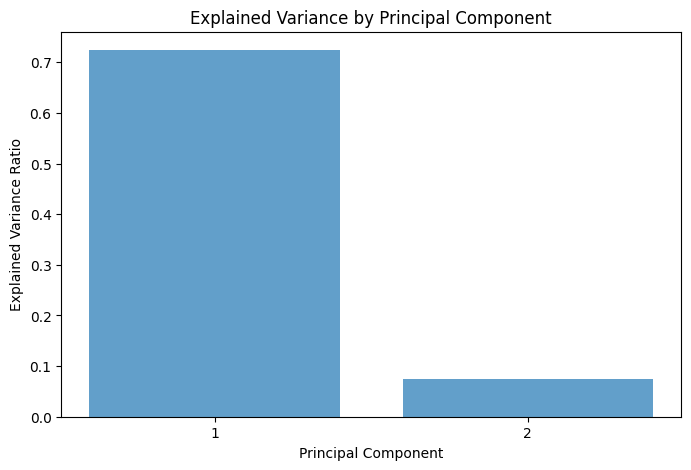

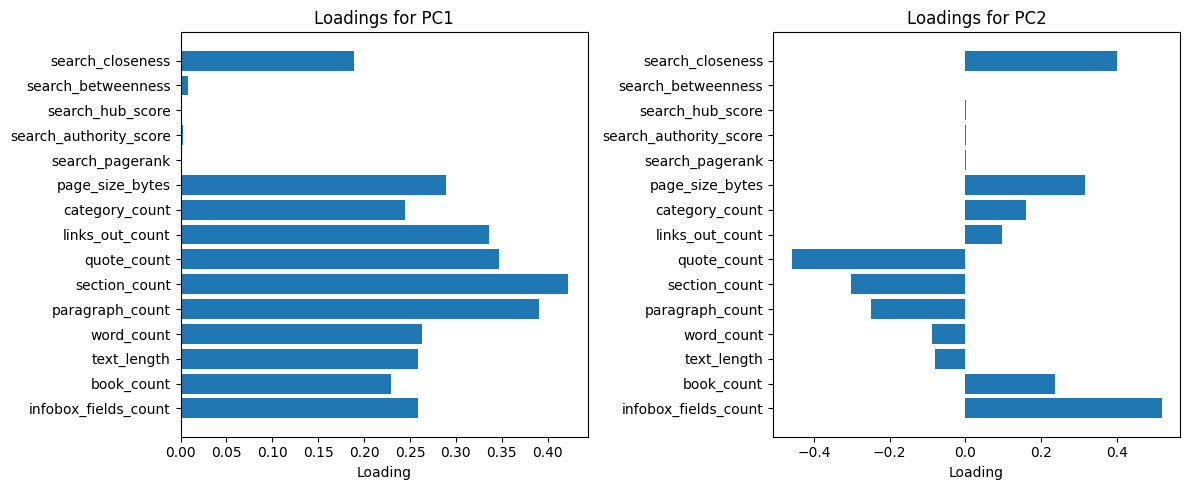

In [48]:
# Plot explained variance ratio for each principal component
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.show()

# Optionally, plot the loadings (components) for each variable per component
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i in range(2):
    ax[i].barh(numeric_cols, pca.components_[i])
    ax[i].set_title(f'Loadings for PC{i+1}')
    ax[i].set_xlabel('Loading')
plt.tight_layout()
plt.show()

## 8. Distance Features

For each character we compute its Euclidean and Minkowski (p=3) distance from the origin in the normalized feature space. Characters with high distance are 'extreme' across multiple dimensions — useful as a novelty or diversity signal in search ranking.

In [49]:
distance_columns = numeric_cols

master_df.loc[:, 'euclidean_distance'] = master_df[distance_columns].fillna(0).apply(
    lambda row: distance.euclidean(row.values, [0] * len(row)), axis=1
)
master_df.loc[:, 'minkowski_distance'] = master_df[distance_columns].fillna(0).apply(
    lambda row: distance.minkowski(row.values, [0] * len(row), p=3), axis=1
)

print(f"Calculated distances using {len(distance_columns)} distance features.")

Calculated distances using 15 distance features.


## 9. Book Role Parsing

The raw `books` column contains strings like `"A Game of Thrones (POV)"`. We parse these into a structured `{book_title: role}` dictionary per character, normalising roles into four categories: `pov`, `appears`, `mentioned`, `appendix`.

In [50]:
unique_books = master_df['books'].explode().unique()
unique_books

array(['Fire & Blood (mentioned)', 'The Rise of the Dragon (mentioned)',
       'A Game of Thrones (appears)', 'A Clash of Kings (appears)',
       'A Storm of Swords (appears)', 'A Feast for Crows (appears)',
       'A Dance with Dragons (appendix)',
       'The World of Ice & Fire (mentioned)',
       'The Princess and the Queen (mentioned)',
       'The Sons of the Dragon (mentioned)',
       'A Feast for Crows (mentioned)', 'The Sworn Sword (mentioned)',
       'The Mystery Knight (mentioned)', 'A Clash of Kings (mentioned)',
       'A Feast for Crows (appendix)', 'A Dance with Dragons (mentioned)',
       'A Clash of Kings (appendix)', 'A Storm of Swords (appendix)',
       'The World of Ice & Fire (appendix)',
       'The Rogue Prince (mentioned)', 'The Hedge Knight (mentioned)',
       'A Game of Thrones (mentioned)', 'A Storm of Swords (mentioned)',
       'Fire & Blood (lineages)', 'The Hedge Knight (appears)',
       'The Sworn Sword (appears)', 'The Mystery Knight (appears)'

In [51]:
def clean_book_data(book_data):
    """
    Parses messy book strings into a clean dictionary of {Book_Name: Role}
    """
    # 1. Safely check for NaN (only if it's a float)
    if isinstance(book_data, float) and pd.isna(book_data):
        return {}
        
    # 2. Convert NumPy arrays to standard Python lists
    if isinstance(book_data, np.ndarray):
        book_data = book_data.tolist()
        
    # 3. Safely evaluate strings that look like lists "['book1', 'book2']"
    if isinstance(book_data, str) and book_data.startswith('['):
        try:
            book_data = ast.literal_eval(book_data)
        except:
            pass
            
    # 4. Convert single strings into a list so we can loop uniformly
    if isinstance(book_data, str):
        book_data = [book_data]
        
    # 5. Safety catch: if it's still not a list/tuple, return empty
    if not isinstance(book_data, (list, tuple)):
        return {}
        
    parsed_dict = {}
    for item in book_data:
        # Ignore sub-items that might be NaN
        if isinstance(item, float) and pd.isna(item):
            continue
            
        # This regex looks for: (Any text) followed by (Text in parentheses)
        matches = re.findall(r'([^()]+?)\s*\(([^)]+)\)', str(item))
        
        for book, role in matches:
            # Standardize the Book Title
            book = book.strip()
            book = book.replace(' and ', ' & ') # Unify "and" with "&"
            
            # Standardize the Role
            role = role.strip().lower()
            if 'appedix' in role or 'appendix' in role: 
                role = 'appendix'
            elif 'pov' in role:
                role = 'pov'
            elif 'appear' in role:
                role = 'appears'
            elif 'mention' in role:
                role = 'mentioned'
            else:
                role = 'other' 
                
            parsed_dict[book] = role
            
    return parsed_dict

# Apply the cleaning function to create a new, structured column
master_df['books_parsed'] = master_df['books'].apply(clean_book_data)

# Let's peek at the clean unique roles we successfully extracted
all_roles = set(role for d in master_df['books_parsed'] for role in d.values())
print("Cleaned Roles Found:", all_roles)

Cleaned Roles Found: {'other', 'mentioned', 'pov', 'appendix', 'appears'}


## 10. Top Characters by Ranking Signal

A quick side-by-side view of the top 10 characters ranked by each metric, useful for a sanity check before building the search engine.

In [52]:
pd.concat({
    'pagerank': master_df.sort_values(by='search_pagerank', ascending=False).head(10)[['title', 'search_pagerank']].reset_index(drop=True),
    'betweeness': master_df.sort_values(by='search_betweenness', ascending=False).head(10)[['title', 'search_betweenness']].reset_index(drop=True),
    'closeness': master_df.sort_values(by='search_closeness', ascending=False).head(10)[['title', 'search_closeness']].reset_index(drop=True),
    'euclidian': master_df.sort_values(by='euclidean_distance', ascending=False).head(10)[['title', 'euclidean_distance']].reset_index(drop=True),
    'minkowski': master_df.sort_values(by='minkowski_distance', ascending=False).head(10)[['title', 'minkowski_distance']].reset_index(drop=True)
}, axis=1)

pagerank                             betweeness  \
                title search_pagerank                  title   
0    Tyrion Lannister        0.007974       Tyrion Lannister   
1     Jaime Lannister        0.007154        Jaime Lannister   
2   Stannis Baratheon        0.006590            Walder Frey   
3    Cersei Lannister        0.006230               Jon Snow   
4     Tywin Lannister        0.006207      Stannis Baratheon   
5        Eddard Stark        0.006059             Robb Stark   
6          Robb Stark        0.005946     Maegor I Targaryen   
7            Jon Snow        0.005927           Eddard Stark   
8  Maegor I Targaryen        0.005856       Cersei Lannister   
9          Arya Stark        0.005563  Jaehaerys I Targaryen   

                               closeness                   \
  search_betweenness               title search_closeness   
0           0.055286    Tyrion Lannister         0.517313   
1           0.053650   Stannis Baratheon         0.512880   
2           0.051160          Robb Stark         0.506165   
3           0.046022   Joffrey Baratheon         0.503829   
4           0.041828        Eddard Stark         0.500972   
5           0.041802    Cersei Lannister         0.500162   
6           0.041576    Tommen Baratheon         0.498952   
7           0.033567     Jaime Lannister         0.497747   
8           0.033378     Tywin Lannister         0.495091   
9           0.033329  Daenerys Targaryen         0.484491   

               euclidian                                 minkowski  \
                   title euclidean_distance                  title   
0  Jaehaerys I Targaryen           2.662182  Jaehaerys I Targaryen   
1      Stannis Baratheon           2.543330      Stannis Baratheon   
2        Jaime Lannister           2.525279        Jaime Lannister   
3     Robert I Baratheon           2.496848     Robert I Baratheon   
4     Daenerys Targaryen           2.474826     Daenerys Targaryen   
5       Cersei Lannister           2.451034       Cersei Lannister   
6        Tywin Lannister           2.426060        Tywin Lannister   
7    Aegon III Targaryen           2.358449    Aegon III Targaryen   
8     Aerys II Targaryen           2.305206     Aerys II Targaryen   
9       Tyrion Lannister           2.268093       Tyrion Lannister   

                      
  minkowski_distance  
0           1.842936  
1           1.741350  
2           1.725828  
3           1.702632  
4           1.688191  
5           1.678530  
6           1.659165  
7           1.615073  
8           1.573730  
9           1.556247

## 11. Save Processed Data

Persist `master_df` as both CSV (human-readable) and pickle (lossless for lists/dicts) before moving on to the search layer.

In [53]:
master_df.to_csv('./data/got_characters.csv', index=False)
master_df.to_pickle('./data/got_characters.pkl')
print("Saved master_df to ./data/")

Saved master_df to ./data/


## 12. Search Engine

A three-stage retrieval pipeline:

1. **Stage 0 — Context filter**: optionally restrict candidates to characters appearing in a specific book.
2. **Stage 1 — Retrieval**: find candidates via exact match, Jaccard similarity, or TF-IDF cosine similarity.
3. **Stage 2 — Ranking**: score candidates by a chosen metric (`hybrid`, `jaccard`, `tfidf`, `search_betweenness`, `euclidean_distance`, or any numeric column).

The `hybrid` ranker combines TF-IDF score, title/alias boost, PageRank, Closeness, and a contextual book-role boost.

In [54]:
# =========================================================
# 1. DATA PREPARATION & CLEANING
# =========================================================
# Ensure core text columns are safe
master_df['text'] = master_df['text'].fillna('')
master_df['title'] = master_df['title'].fillna('')


# =========================================================
# 2. GLOBAL SEARCH UTILITIES
# =========================================================
# Initialize and fit TF-IDF vectorizer once
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(master_df['text'])

def get_jaccard_sim(str1, str2): 
    a = set(re.findall(r'\w+', str1.lower())) 
    b = set(re.findall(r'\w+', str2.lower()))
    if not a or not b: return 0.0
    c = a.intersection(b)
    return float(len(c)) / (len(a) + len(b) - len(c))

ROLE_BOOSTS = {'pov': 2.0, 'appears': 1.0, 'mentioned': 0.2, 'other': 0.1, 'appendix': 0.0}

# =========================================================
# 3. THE DYNAMIC SEARCH ENGINE
# =========================================================
def advanced_search_dynamic(query_name, df, current_book=None, retrieve_by='tfidf', rank_by='hybrid', top_n=5):
    """
    Dynamic 3-Stage Search Pipeline: Context -> Retrieval -> Custom Ranking
    """
    query_lower = query_name.lower()
    
    # Pre-calculate TF-IDF for all rows safely
    query_vec = tfidf_vectorizer.transform([query_lower])
    tfidf_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    working_df = df.copy()
    working_df['tfidf_base_score'] = tfidf_scores
    
    # ---------------------------------------------------------
    # STAGE 0: CONTEXTUAL FILTERING (Hard Book Filter)
    # ---------------------------------------------------------
    if current_book:
        book_mask = working_df['books_parsed'].apply(lambda x: current_book in x)
        working_df = working_df[book_mask].copy()
        if working_df.empty:
            print(f"No candidates found in book: '{current_book}'")
            return pd.DataFrame(columns=['title', 'final_score'])

    # ---------------------------------------------------------
    # STAGE 1: RETRIEVAL (Finding Candidates)
    # ---------------------------------------------------------
    if retrieve_by == 'exact':
        mask = working_df['text'].str.lower().str.contains(query_lower, regex=False)
        retrieved_df = working_df[mask].copy()
    elif retrieve_by == 'jaccard':
        working_df['jaccard_base_score'] = working_df['text'].apply(lambda x: get_jaccard_sim(query_lower, x))
        retrieved_df = working_df[working_df['jaccard_base_score'] > 0].copy()
    elif retrieve_by == 'tfidf':
        retrieved_df = working_df[working_df['tfidf_base_score'] > 0].copy()
    else:
        raise ValueError("retrieve_by must be 'exact', 'jaccard', or 'tfidf'")
        
    if retrieved_df.empty:
        print("No candidates matched the retrieval criteria.")
        return pd.DataFrame(columns=['title', 'final_score'])

    # ---------------------------------------------------------
    # STAGE 2: DYNAMIC RANKING (Sorting Candidates)
    # ---------------------------------------------------------
    if rank_by == 'none':
        retrieved_df['final_score'] = 1.0 
        
    elif rank_by == 'jaccard':
        if 'jaccard_base_score' not in retrieved_df.columns:
            retrieved_df['final_score'] = retrieved_df['text'].apply(lambda x: get_jaccard_sim(query_lower, x))
        else:
            retrieved_df['final_score'] = retrieved_df['jaccard_base_score']
            
    elif rank_by == 'tfidf':
        retrieved_df['final_score'] = retrieved_df['tfidf_base_score']
        
    elif rank_by == 'hybrid':
        scores = []
        for idx, row in retrieved_df.iterrows():
            score = row['tfidf_base_score']
            
            # Metadata Boosts (Titles and Aliases)
            if query_lower in str(row['title']).lower(): score += 0.5
            aliases = row.get('aliases', [])
            if isinstance(aliases, str) and aliases.startswith('['):
                try: aliases = ast.literal_eval(aliases)
                except: aliases = []
            if isinstance(aliases, list) and any(query_lower in str(a).lower() for a in aliases):
                score += 0.3
            elif isinstance(aliases, str) and query_lower in aliases.lower():
                score += 0.3
                
            # Network Connectivity Boost
            score += (row.get('search_pagerank', 0.0) * 10)
            score += row.get('search_closeness', 0.0)
            
            # Contextual Role Boost (If reading a specific book)
            if current_book:
                character_role = row['books_parsed'].get(current_book, 'appendix')
                score += ROLE_BOOSTS.get(character_role, 0.0)
                
            scores.append(score)
        retrieved_df['final_score'] = scores
        
    # --- THE DYNAMIC COLUMN CHECK ---
    elif rank_by in retrieved_df.columns:
        retrieved_df['final_score'] = pd.to_numeric(retrieved_df[rank_by], errors='coerce').fillna(0.0)
    else:
        raise ValueError(f"rank_by '{rank_by}' is not recognized or not a column in the DataFrame.")
        
    # ---------------------------------------------------------
    # STAGE 3: SMART SORTING
    # ---------------------------------------------------------
    # If the ranking metric has 'distance' in its name, smaller is better (Ascending)
    # Otherwise, higher score is better (Descending)
    is_distance_metric = 'distance' in rank_by.lower()
    
    sorted_results = retrieved_df.sort_values(
        by='final_score', 
        ascending=is_distance_metric 
    )
    
    if current_book:
        # Extract the specific role they had in the current book to display it
        sorted_results['context_role'] = sorted_results['books_parsed'].apply(
            lambda x: x.get(current_book, 'appendix')
        )
        # Return the title, the score, and their role in the book
        return sorted_results[['title', 'final_score', 'context_role']].head(top_n)
    else:
        # Standard return if no book context was provided
        return sorted_results[['title', 'final_score']].head(top_n)

# =========================================================

## 13. Build Search Index DataFrame

We create a lighter `search_df` containing only the columns needed at query time — reducing memory overhead when the search engine is deployed independently.

In [55]:
# 1. Select all core features PLUS all your experimental ranking features
search_columns = [
    'title', 'text', 'aliases', 'books_parsed', 
    'search_pagerank', 'search_authority_score', 'search_hub_score', 
    'search_betweenness', 'search_closeness', 
    'euclidean_distance', 'minkowski_distance',
    'word_count', 'links_out_count' # These are also fun to rank by!
]

# 2. Create the expanded DataFrame
search_df = master_df[search_columns].copy()

# Fill any NaNs in the numeric columns with 0.0 to prevent sorting errors
numeric_cols = ['search_pagerank', 'search_authority_score', 'search_hub_score', 
                'search_betweenness', 'search_closeness', 'euclidean_distance', 
                'minkowski_distance', 'word_count', 'links_out_count']

for col in numeric_cols:
    if col in search_df.columns:
        search_df[col] = search_df[col].fillna(0.0)

## 14. Search Demos

### 14.1 Global search (no book context)

In [56]:
# RUNNING THE TESTS
# =========================================================

print("--- 1. Rank by DEFAULT HYBRID (Semantic + Network + Context) ---")
display(advanced_search_dynamic("Robert", master_df, retrieve_by='tfidf', rank_by='hybrid'))

print("\n--- 2. Rank by BETWEENNESS (Finds the most central bridge character) ---")
display(advanced_search_dynamic("stark", master_df, retrieve_by='jaccard', rank_by='search_betweenness'))

print("\n--- 3. Rank by EUCLIDEAN DISTANCE (Finds the most mathematically similar node) ---")
# Notice how the function automatically sorts lowest-first for distance metrics!
display(advanced_search_dynamic("stark", master_df, retrieve_by='jaccard', rank_by='euclidean_distance'))

print("\n--- 4. Rank by WORD COUNT (Finds the longest wiki article) ---")
display(advanced_search_dynamic("sword", master_df, retrieve_by='jaccard', rank_by='word_count'))

--- 1. Rank by DEFAULT HYBRID (Semantic + Network + Context) ---


,title,final_score
2754,Robert I Baratheon,1.844964
2744,Robert Arryn,1.553632
2752,Robert Redwyne,1.255495
2749,Robert Quince,1.221688
2756,Robert Frey (son of Raymund),1.141104



--- 2. Rank by BETWEENNESS (Finds the most central bridge character) ---


,title,final_score
3308,Tyrion Lannister,0.055286
1590,Jaime Lannister,0.053650
3439,Walder Frey,0.051160
1729,Jon Snow,0.046022
3063,Stannis Baratheon,0.041828



--- 3. Rank by EUCLIDEAN DISTANCE (Finds the most mathematically similar node) ---


,title,final_score
2672,Redwyn,0.318326
1435,Helly,0.331074
3053,Starved man,0.333036
3042,Squinter,0.333558
2621,Quill,0.348267



--- 4. Rank by WORD COUNT (Finds the longest wiki article) ---


,title,final_score
1584,Jaehaerys I Targaryen,1.000000
713,Daenerys Targaryen,0.884026
3063,Stannis Baratheon,0.828837
1590,Jaime Lannister,0.808575
60,Aerys II Targaryen,0.765029


### 14.2 Book-scoped search (`A Game of Thrones`)

In [57]:
print("--- 1. Retrieved by TFIDF, Ranked by DEFAULT HYBRID (Semantic + Network + Context) ---")
display(advanced_search_dynamic("stark", master_df, current_book='A Game of Thrones', retrieve_by='tfidf', rank_by='hybrid'))

print("\n--- 2. Retrieved by JACCARD, Ranked by BETWEENNESS (Finds the most central bridge character) ---")
display(advanced_search_dynamic("stark", master_df, current_book='A Game of Thrones', retrieve_by='jaccard', rank_by='search_betweenness'))

print("\n--- 3. Retrieved by JACCARD, Ranked by EUCLIDEAN DISTANCE (Finds the most mathematically similar node) ---")
# Notice how the function automatically sorts lowest-first for distance metrics!
display(advanced_search_dynamic("stark", master_df, current_book='A Game of Thrones', retrieve_by='jaccard', rank_by='euclidean_distance'))

print("\n--- 4. Retrieved by JACCARD, Ranked by WORD COUNT (Finds the longest wiki article) ---")
display(advanced_search_dynamic("stark", master_df, current_book='A Game of Thrones', retrieve_by='jaccard', rank_by='word_count'))

print("\n--- 5. Retrieved by JACCARD, Ranked by HYBRID (Finds the longest wiki article) ---")
display(advanced_search_dynamic("stark", master_df, current_book='A Game of Thrones', retrieve_by='jaccard', rank_by='hybrid'))

--- 1. Retrieved by TFIDF, Ranked by DEFAULT HYBRID (Semantic + Network + Context) ---


,title,final_score,context_role
568,Catelyn Stark,3.389547,pov
919,Eddard Stark,3.172144,pov
2950,Sansa Stark,3.083624,pov
269,Arya Stark,3.077864,pov
485,Bran Stark,3.054652,pov



--- 2. Retrieved by JACCARD, Ranked by BETWEENNESS (Finds the most central bridge character) ---


,title,final_score,context_role
3308,Tyrion Lannister,0.055286,pov
1590,Jaime Lannister,0.053650,appears
3439,Walder Frey,0.051160,appears
1729,Jon Snow,0.046022,pov
3063,Stannis Baratheon,0.041828,mentioned



--- 3. Retrieved by JACCARD, Ranked by EUCLIDEAN DISTANCE (Finds the most mathematically similar node) ---


,title,final_score,context_role
1221,Gladden Wylde,0.432393,appears
2415,Orland of Oldtown,0.464027,appears
2551,Porther,0.485418,appears
2794,Rodrik Stark,0.506371,mentioned
1292,Gunthor,0.517995,appears



--- 4. Retrieved by JACCARD, Ranked by WORD COUNT (Finds the longest wiki article) ---


,title,final_score,context_role
1584,Jaehaerys I Targaryen,1.000000,mentioned
713,Daenerys Targaryen,0.884026,pov
3063,Stannis Baratheon,0.828837,mentioned
592,Cersei Lannister,0.815739,appears
1590,Jaime Lannister,0.808575,appears



--- 5. Retrieved by JACCARD, Ranked by HYBRID (Finds the longest wiki article) ---


,title,final_score,context_role
568,Catelyn Stark,3.389547,pov
919,Eddard Stark,3.172144,pov
2950,Sansa Stark,3.083624,pov
269,Arya Stark,3.077864,pov
485,Bran Stark,3.054652,pov


### 14.3 Natural-language / semantic query

In [58]:
print("--- Retrieved by TFIDF, Ranked by DEFAULT HYBRID (Semantic + Network + Context) ---")
display(advanced_search_dynamic("the honorable lord of winterfell who was executed in king's landing", master_df, current_book='A Game of Thrones', retrieve_by='tfidf', rank_by='hybrid'))

--- Retrieved by TFIDF, Ranked by DEFAULT HYBRID (Semantic + Network + Context) ---


,title,final_score,context_role
919,Eddard Stark,2.671757,pov
3308,Tyrion Lannister,2.644113,pov
568,Catelyn Stark,2.602635,pov
1729,Jon Snow,2.585394,pov
2950,Sansa Stark,2.580892,pov


## 15. Save Search Index

In [ ]:
search_df.to_pickle('./data/got_search_engine_df.pkl')